<a href="https://colab.research.google.com/github/marcomunozq-miaad-uacj/Programacion1Semestre/blob/main/Representaci%C3%B3n_de_textos_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [146]:
# esta celda instala las librerias que voy a usar en colab
# gensim me sirve para entrenar los embeddings con word2vec
# nltk me ayuda con las stopwords
# adjusttext me ayuda a acomodar un poco mejor las etiquetas en la grafica

!pip install -q gensim nltk adjustText

In [147]:
# aqui importo todas las librerias que voy a ocupar

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

import nltk
from nltk.corpus import stopwords

from gensim.models import Word2Vec

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

from adjustText import adjust_text
from matplotlib.patches import Ellipse

In [148]:
# aqui descargo las stopwords en español
# esto solo se hace una vez en el entorno de colab

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [149]:
# esta celda conecta google colab con mi google drive
# cuando la ejecute se abrira un enlace para autorizar el acceso

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [150]:
# aqui pongo la ruta completa del archivo dentro de mi google drive

ruta_archivo = "/content/drive/MyDrive/Colab Notebooks/Semestre2/PLN/Semana 7/Ejercicios de Representación de textos - Embeddings.csv"
df = pd.read_csv(ruta_archivo)

# muestro las primeras filas para confirmar que si cargo bien
df.head(10)

,frase
0,La ciberseguridad protege la información digit...
1,La inteligencia artificial transforma múltiple...
2,"El baloncesto combina velocidad, técnica y tra..."
3,El hardware y el software son complementarios ...
4,La democracia permite la participación ciudada...
5,La natación es una disciplina que fortalece to...
6,Los algoritmos son la base de la programación ...
7,El hardware y el software son complementarios ...
8,El hardware y el software son complementarios ...
9,Los algoritmos son la base de la programación ...


In [151]:
# aqui reviso cuantas filas hay y como se llama la columna del texto

print("forma del dataset:", df.shape)
print("\ncolumnas:")
print(df.columns)

print("\nprimeras frases:")
for i, texto in enumerate(df.iloc[:5, 0]):
    print(f"{i+1}. {texto}")

forma del dataset: (148, 1)

columnas:
Index(['frase'], dtype='object')

primeras frases:
1. La ciberseguridad protege la información digital. 
2. La inteligencia artificial transforma múltiples industrias. 
3. El baloncesto combina velocidad, técnica y trabajo en equipo. 
4. El hardware y el software son complementarios en la computación. 
5. La democracia permite la participación ciudadana en decisiones. 


In [152]:
# aqui creo una lista de stopwords en español
# tambien agrego algunas palabras que a a mi criterio no ayudan mucho en el analisis, solo para experimentar

stopwords_es = set(stopwords.words("spanish"))

stopwords_extra = {
    "si", "solo", "asi", "tambien", "cada", "puede", "pueden",
    "ser", "hacer", "hace", "hacerse", "través", "traves"
}

stopwords_es = stopwords_es.union(stopwords_extra)

print("cantidad total de stopwords:", len(stopwords_es))

cantidad total de stopwords: 326


In [153]:
# aqui hago una funcion para limpiar cada texto
# convierto a minusculas
# quito signos raros y numeros
# dejo solo letras y espacios
# luego separo el texto en palabras
# finalmente quito stopwords y palabras muy cortas

def limpiar_y_tokenizar(texto):
    texto = str(texto).lower()
    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)
    tokens = texto.split()
    tokens_limpios = [
        palabra for palabra in tokens
        if palabra not in stopwords_es and len(palabra) > 2
    ]
    return tokens_limpios

# aqui aplico la funcion a la primera columna del dataset
columna_texto = df.columns[0]
df["tokens"] = df[columna_texto].apply(limpiar_y_tokenizar)

# reviso algunos resultados
df[[columna_texto, "tokens"]].head(3)

,frase,tokens
0,La ciberseguridad protege la información digit...,"[ciberseguridad, protege, información, digital]"
1,La inteligencia artificial transforma múltiple...,"[inteligencia, artificial, transforma, múltipl..."
2,"El baloncesto combina velocidad, técnica y tra...","[baloncesto, combina, velocidad, técnica, trab..."


In [154]:
# aqui imprimo algunos ejemplos para entender como quedo el preprocesamiento

for i in range(10):
    print(f"frase original {i+1}:")
    print(df.loc[i, columna_texto])
    print(" " * 100)
    print("tokens:")
    print(df.loc[i, "tokens"])
    print("-" * 100)

frase original 1:
La ciberseguridad protege la información digital. 
                                                                                                    
tokens:
['ciberseguridad', 'protege', 'información', 'digital']
----------------------------------------------------------------------------------------------------
frase original 2:
La inteligencia artificial transforma múltiples industrias. 
                                                                                                    
tokens:
['inteligencia', 'artificial', 'transforma', 'múltiples', 'industrias']
----------------------------------------------------------------------------------------------------
frase original 3:
El baloncesto combina velocidad, técnica y trabajo en equipo. 
                                                                                                    
tokens:
['baloncesto', 'combina', 'velocidad', 'técnica', 'trabajo', 'equipo']
-------------------------------------------

In [155]:
# aqui junto todos los tokens de todas las frases
# luego cuento cuantas veces aparece cada palabra

todas_las_palabras = [palabra for lista in df["tokens"] for palabra in lista]
frecuencias = Counter(todas_las_palabras)

# muestro las 30 palabras mas frecuentes
frecuencias.most_common(30)

[('fortalece', 21),
 ('permite', 14),
 ('ciberseguridad', 13),
 ('protege', 13),
 ('información', 13),
 ('digital', 13),
 ('natación', 13),
 ('disciplina', 13),
 ('cuerpo', 13),
 ('elecciones', 13),
 ('libres', 13),
 ('esenciales', 13),
 ('derecho', 13),
 ('inteligencia', 11),
 ('artificial', 11),
 ('transforma', 11),
 ('múltiples', 11),
 ('industrias', 11),
 ('baloncesto', 11),
 ('combina', 11),
 ('velocidad', 11),
 ('técnica', 11),
 ('trabajo', 11),
 ('equipo', 11),
 ('hardware', 10),
 ('software', 10),
 ('complementarios', 10),
 ('computación', 10),
 ('algoritmos', 10),
 ('base', 10)]

In [156]:
# aqui preparo el corpus final para entrenar word2vec
# solo tomo las listas de tokens que tengan al menos 2 palabras

corpus = [tokens for tokens in df["tokens"] if len(tokens) >= 2]

print("cantidad de frases utiles:", len(corpus))
print("3 ejemplo de frase tokenizada:")
print(corpus[0])
print(corpus[1])
print(corpus[2])

cantidad de frases utiles: 148
3 ejemplo de frase tokenizada:
['ciberseguridad', 'protege', 'información', 'digital']
['inteligencia', 'artificial', 'transforma', 'múltiples', 'industrias']
['baloncesto', 'combina', 'velocidad', 'técnica', 'trabajo', 'equipo']


In [157]:
# aqui entreno el modelo de embeddings
# vector_size es el tamaño de cada vector
# window dice cuantas palabras vecinas voy a considerar
# min_count=1 deja entrar cualquier palabra que aparezca al menos una vez
# workers acelera el entrenamiento
# seed es la semilla que ayuda a que el resultado sea reproducible

modelo_w2v = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=3,
    min_count=1,
    workers=4,
    sg=1,
    seed=42
)

print("cantidad de palabras en el vocabulario:", len(modelo_w2v.wv.index_to_key))
print("algunas palabras del vocabulario:")
print(modelo_w2v.wv.index_to_key[:20])

cantidad de palabras en el vocabulario: 71
algunas palabras del vocabulario:
['fortalece', 'permite', 'derecho', 'esenciales', 'libres', 'elecciones', 'cuerpo', 'disciplina', 'natación', 'digital', 'información', 'protege', 'ciberseguridad', 'equipo', 'trabajo', 'técnica', 'velocidad', 'combina', 'baloncesto', 'industrias']


In [158]:
# aqui elijo las palabras que voy a mostrar en la grafica
# no conviene poner demasiadas porque se enciman
# por eso tomo las palabras mas frecuentes

top_n = 60

palabras_seleccionadas = [
    palabra for palabra, freq in frecuencias.most_common(top_n)
    if palabra in modelo_w2v.wv
]

print("cantidad de palabras seleccionadas:", len(palabras_seleccionadas))
print(palabras_seleccionadas)

cantidad de palabras seleccionadas: 60
['fortalece', 'permite', 'ciberseguridad', 'protege', 'información', 'digital', 'natación', 'disciplina', 'cuerpo', 'elecciones', 'libres', 'esenciales', 'derecho', 'inteligencia', 'artificial', 'transforma', 'múltiples', 'industrias', 'baloncesto', 'combina', 'velocidad', 'técnica', 'trabajo', 'equipo', 'hardware', 'software', 'complementarios', 'computación', 'algoritmos', 'base', 'programación', 'informática', 'olimpismo', 'busca', 'unión', 'pueblos', 'deporte', 'políticas', 'públicas', 'buscan', 'atender', 'necesidades', 'sociales', 'partidos', 'políticos', 'representan', 'diferentes', 'ideologías', 'fútbol', 'deportes', 'populares', 'mundo', 'democracia', 'participación', 'ciudadana', 'decisiones', 'debate', 'público', 'vida', 'democrática']


In [159]:
# aqui convierto cada palabra seleccionada en su vector numerico

X = np.array([modelo_w2v.wv[palabra] for palabra in palabras_seleccionadas])

print("forma de la matriz de embeddings:", X.shape)

forma de la matriz de embeddings: (60, 100)


In [160]:
# aqui uso t-sne para pasar de 100 dimensiones a 2
# eso me permite graficar cada palabra en el plano
# perplexity se relaciona con cuantos vecinos considera t-sne
# learning_rate='auto' deja que sklearn ajuste ese valor
# init='pca' ayuda a que el resultado sea mas estable

tsne = TSNE(
    n_components=2,
    perplexity=10,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_2d = tsne.fit_transform(X)

print("forma despues de t-sne:", X_2d.shape)

forma despues de t-sne: (60, 2)


In [161]:
# aqui hago clusters solo como apoyo visual
# puedes cambiar el numero de clusters si en la grafica ves mas o menos grupos
# yo escogi 5 clusters porque son los que me parecen mas naturales, jugue con este parametro un rato para ver los clusters

num_clusters = 11

kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
labels_cluster = kmeans.fit_predict(X_2d)

print("clusters asignados:")
print(labels_cluster)

clusters asignados:
[10 10  6  9  4  1  0  4  4  6  7  4  0  7  6  1  1  8  3 10  2  9  8  7
  0  0  0  1  2 10 10  4  2  4  5  8  3  1  5  3  7  5  6  6  5  7  5  6
  3  8  3  9  7  1  1  5  7  9  4  1]


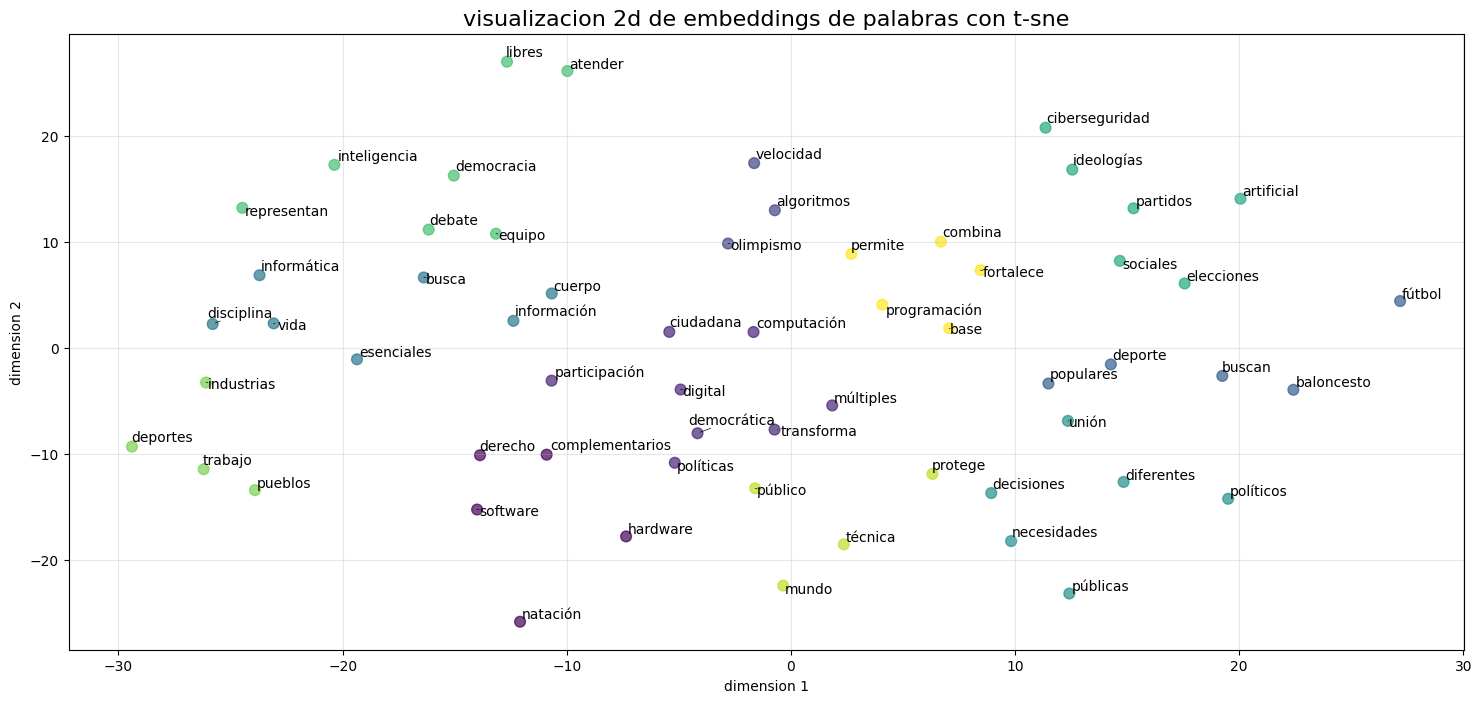

In [162]:
# aqui hago la grafica principal
# cada punto representa una palabra
# tambien escribo la palabra junto al punto
# uso adjust_text para que las etiquetas no se monten tanto

plt.figure(figsize=(18, 8))

scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=labels_cluster,
    s=60,
    alpha=0.7
)

textos = []
for i, palabra in enumerate(palabras_seleccionadas):
    textos.append(
        plt.text(
            X_2d[i, 0],
            X_2d[i, 1],
            palabra,
            fontsize=10
        )
    )

adjust_text(textos, arrowprops=dict(arrowstyle="-", lw=0.5))

plt.title("visualizacion 2d de embeddings de palabras con t-sne", fontsize=16)
plt.xlabel("dimension 1")
plt.ylabel("dimension 2")
plt.grid(alpha=0.3)
plt.show()

In [163]:
# aqui reviso que palabras quedaron en cada cluster
# esto me ayuda a interpretar que dominio tematico puede tener cada grupo

clusters_palabras = {}

# aqui recorro las palabras seleccionadas y el cluster que les asigno kmeans
# zip junta ambas listas para poder recorrerlas al mismo tiempo
for palabra, etiqueta in zip(palabras_seleccionadas, labels_cluster):

    # si el cluster aun no existe en el diccionario lo creo
    if etiqueta not in clusters_palabras:
        clusters_palabras[etiqueta] = []

    # agrego la palabra a la lista de ese cluster
    clusters_palabras[etiqueta].append(palabra)


# aqui imprimo los clusters en orden
# sorted ordena las claves del diccionario (0,1,2,3...)
for etiqueta in sorted(clusters_palabras):

    print(f"\ncluster {etiqueta}:")

    # aqui ordeno alfabeticamente las palabras dentro del cluster
    palabras_ordenadas = sorted(clusters_palabras[etiqueta])

    print(", ".join(palabras_ordenadas))


cluster 0:
complementarios, derecho, hardware, natación, software

cluster 1:
ciudadana, computación, democrática, digital, múltiples, participación, políticas, transforma

cluster 2:
algoritmos, olimpismo, velocidad

cluster 3:
baloncesto, buscan, deporte, fútbol, populares

cluster 4:
busca, cuerpo, disciplina, esenciales, información, informática, vida

cluster 5:
decisiones, diferentes, necesidades, políticos, públicas, unión

cluster 6:
artificial, ciberseguridad, elecciones, ideologías, partidos, sociales

cluster 7:
atender, debate, democracia, equipo, inteligencia, libres, representan

cluster 8:
deportes, industrias, pueblos, trabajo

cluster 9:
mundo, protege, público, técnica

cluster 10:
base, combina, fortalece, permite, programación


# *Extra: Como complemento me interesa ver la grafica en 3D*

In [164]:
# si no tengo plotly instalado, esta celda lo instala
!pip install -q plotly

In [145]:
# aqui importo las librerias necesarias
# plotly me permite hacer una grafica 3d interactiva
# pandas me ayuda a organizar los datos para graficarlos

import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE

# aqui aplico t-sne para reducir los embeddings a 3 dimensiones
# n_components=3 indica que quiero 3 ejes
# perplexity controla como t-sne considera los vecinos cercanos
# random_state me ayuda a que el resultado sea reproducible

tsne_3d = TSNE(
    n_components=3,
    perplexity=10,
    learning_rate="auto",
    init="pca",
    random_state=10
)

# aqui transformo la matriz de embeddings a 3 dimensiones
X_3d = tsne_3d.fit_transform(X)


df_3d = pd.DataFrame({
    "x": X_3d[:, 0],
    "y": X_3d[:, 1],
    "z": X_3d[:, 2],
    "palabra": palabras_seleccionadas
})

fig = px.scatter_3d(
    df_3d,
    x="x",
    y="y",
    z="z",
    text="palabra",
    hover_name="palabra",
    title="visualizacion 3d interactiva de embeddings de palabras con t-sne"
)

fig.update_traces(
    marker=dict(size=5),
    textposition="top center"
)

fig.update_layout(
    width=1000,
    height=800,
    scene=dict(
        xaxis_title="dimension 1",
        yaxis_title="dimension 2",
        zaxis_title="dimension 3"
    )
)

fig.show()